<a href="https://colab.research.google.com/github/Renyambar/Reny_MachineLearning/blob/main/JS05/JS05_Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Langkah 1 – Import Library & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Langkah 2 – Preprocessing
### 2a. Drop kolom yang tidak digunakan

In [2]:
df = df.drop(df.iloc[:, 2:], axis=1)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 2b. Ganti nama kolom

In [3]:
df = df.rename(columns={'v1': 'Labels', 'v2': 'SMS'})
df.head()

,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 2c. Inspeksi data

In [4]:
print('Jumlah data per kelas:')
print(df['Labels'].value_counts())
print('\n')

print('Info data:')
df.info()
print('\n')

print('Statistik deskriptif:')
print(df.describe())

Jumlah data per kelas:
Labels
ham     4825
spam     747
Name: count, dtype: int64


Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Labels  5572 non-null   object
 1   SMS     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Statistik deskriptif:
       Labels                     SMS
count    5572                    5572
unique      2                    5169
top       ham  Sorry, I'll call later
freq     4825                      30


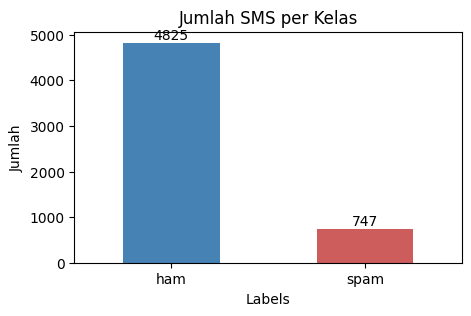

In [5]:
# Visualisasi proporsi kelas
ax = df['Labels'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'], figsize=(5, 3))
plt.title('Jumlah SMS per Kelas')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

### 2d. Encoding label

In [6]:
new_labels = {'spam': 1, 'ham': 0}
df['Labels'] = df['Labels'].map(new_labels)
df.head()

,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### 2e. Pisahkan fitur dan label

In [7]:
X = df['SMS'].values
y = df['Labels'].values

print('Jumlah data X:', len(X))
print('Jumlah data y:', len(y))

Jumlah data X: 5572
Jumlah data y: 5572


## Langkah 3 – Split Data Training dan Testing

In [8]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)

print('Data training:', len(X_train_text))
print('Data testing :', len(X_test_text))
print('Proporsi spam di training:', round(y_train.mean() * 100, 2), '%')
print('Proporsi spam di testing :', round(y_test.mean() * 100, 2), '%')

Data training: 4457
Data testing : 1115
Proporsi spam di training: 13.15 %
Proporsi spam di testing : 14.44 %


## Fungsi untuk Evaluasi

| Metrik | Keterangan |
|---|---|
| **Accuracy** | Dari semua SMS, berapa persen yang ditebak benar |
| **Precision** (spam) | Dari SMS yang diprediksi spam, berapa persen yang benar-benar spam. Precision rendah berarti banyak SMS normal salah masuk spam |
| **Recall** (spam) | Dari semua SMS spam yang sebenarnya, berapa persen yang berhasil terdeteksi. Recall rendah berarti banyak spam lolos |
| **F1-score** | Rata-rata harmonis precision dan recall (nilai keseimbangan keduanya) |
| **Confusion matrix** | Tabel jumlah tebakan benar/salah per kelas |

In [9]:
def evaluasi_model(nama, model, X_train, X_test, y_train, y_test):
    """Hitung metrik evaluasi, tampilkan, dan kembalikan dalam bentuk dict."""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    hasil = {
        'Model': nama,
        'Akurasi Train': accuracy_score(y_train, y_pred_train),
        'Akurasi Test': accuracy_score(y_test, y_pred_test),
        'Precision (spam)': precision_score(y_test, y_pred_test),
        'Recall (spam)': recall_score(y_test, y_pred_test),
        'F1-score (spam)': f1_score(y_test, y_pred_test),
    }

    print(f'=== {nama} ===')
    print(f"Hasil akurasi data train: {hasil['Akurasi Train']:.4f}")
    print(f"Hasil akurasi data test : {hasil['Akurasi Test']:.4f}\n")
    print('Classification report (data test):')
    print(classification_report(y_test, y_pred_test, target_names=['ham (0)', 'spam (1)'], digits=4))

    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix\n{nama}')
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f'Ham benar dikenali (TN) : {tn}')
    print(f'Ham salah jadi spam (FP): {fp}  <- SMS penting bisa terblokir')
    print(f'Spam lolos jadi ham (FN): {fn}  <- spam masuk inbox')
    print(f'Spam benar dikenali (TP): {tp}')
    return hasil


# TUGAS 1 – Multinomial Naive Bayes + `CountVectorizer` (stop words aktif)

## Langkah 1.1 – Ekstraksi Fitur dengan CountVectorizer

In [10]:
# Inisiasi CountVectorizer dengan stop words
bow = CountVectorizer(stop_words='english')

# Fit + transform pada data training
X_train_bow = bow.fit_transform(X_train_text)

# Transform saja pada data testing
X_test_bow = bow.transform(X_test_text)

print('Jumlah fitur (kata unik):', len(bow.get_feature_names_out()))
print('Dimensi data training   :', X_train_bow.shape)
print('Dimensi data testing    :', X_test_bow.shape)

Jumlah fitur (kata unik): 7466
Dimensi data training   : (4457, 7466)
Dimensi data testing    : (1115, 7466)


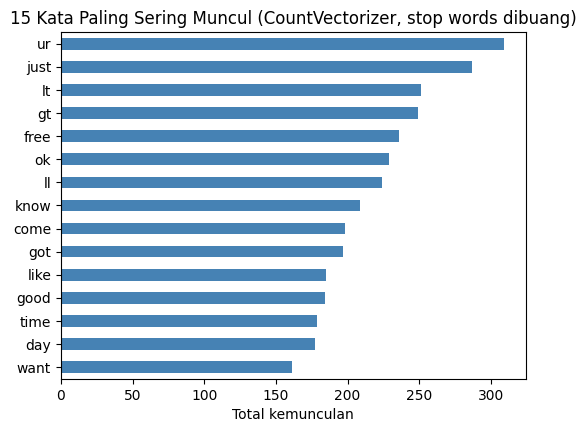

In [11]:
# Total kemunculan setiap kata di data training
jumlah_kata = np.asarray(X_train_bow.sum(axis=0)).ravel()
kata = bow.get_feature_names_out()

top_bow = (pd.Series(jumlah_kata, index=kata)
             .sort_values(ascending=False).head(15))

top_bow.sort_values().plot(kind='barh', figsize=(6, 4.5), color='steelblue')
plt.title('15 Kata Paling Sering Muncul (CountVectorizer, stop words dibuang)')
plt.xlabel('Total kemunculan')
plt.show()

## Langkah 1.2 – Training Model Multinomial Naive Bayes

In [12]:
mnb_bow = MultinomialNB()
mnb_bow.fit(X_train_bow, y_train)

MultinomialNB()

## Langkah 1.3 – Evaluasi Model

=== MNB + CountVectorizer (stop_words) ===
Hasil akurasi data train: 0.9946
Hasil akurasi data test : 0.9830

Classification report (data test):
              precision    recall  f1-score   support

     ham (0)     0.9835    0.9969    0.9901       954
    spam (1)     0.9797    0.9006    0.9385       161

    accuracy                         0.9830      1115
   macro avg     0.9816    0.9487    0.9643      1115
weighted avg     0.9829    0.9830    0.9827      1115



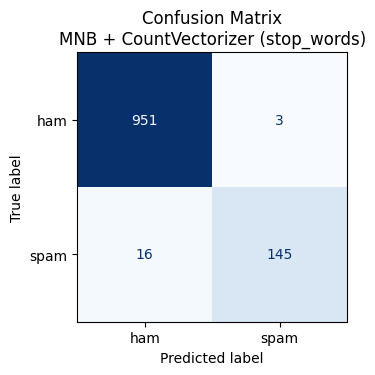

Ham benar dikenali (TN) : 951
Ham salah jadi spam (FP): 3  <- SMS penting bisa terblokir
Spam lolos jadi ham (FN): 16  <- spam masuk inbox
Spam benar dikenali (TP): 145


In [13]:
hasil_bow = evaluasi_model('MNB + CountVectorizer (stop_words)',
                           mnb_bow, X_train_bow, X_test_bow, y_train, y_test)

---
# TUGAS 2 – Multinomial Naive Bayes + `TF-IDF` (stop words aktif)

## Langkah 2.1 – Ekstraksi Fitur dengan `TfidfVectorizer`

In [14]:
# Inisiasi TfidfVectorizer dengan stop words bahasa Inggris aktif
tfidf = TfidfVectorizer(stop_words='english')

# Fit + transform pada data training
X_train_tfidf = tfidf.fit_transform(X_train_text)

# Transform saja pada data testing
X_test_tfidf = tfidf.transform(X_test_text)

print('Jumlah fitur (kata unik):', len(tfidf.get_feature_names_out()))
print('Dimensi data training   :', X_train_tfidf.shape)
print('Dimensi data testing    :', X_test_tfidf.shape)

Jumlah fitur (kata unik): 7466
Dimensi data training   : (4457, 7466)
Dimensi data testing    : (1115, 7466)


## Langkah 2.2 – Training Model Multinomial Naive Bayes

In [15]:
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

## Langkah 2.3 – Evaluasi Model

=== MNB + TF-IDF (stop_words) ===
Hasil akurasi data train: 0.9843
Hasil akurasi data test : 0.9605

Classification report (data test):
              precision    recall  f1-score   support

     ham (0)     0.9559    1.0000    0.9775       954
    spam (1)     1.0000    0.7267    0.8417       161

    accuracy                         0.9605      1115
   macro avg     0.9780    0.8634    0.9096      1115
weighted avg     0.9623    0.9605    0.9579      1115



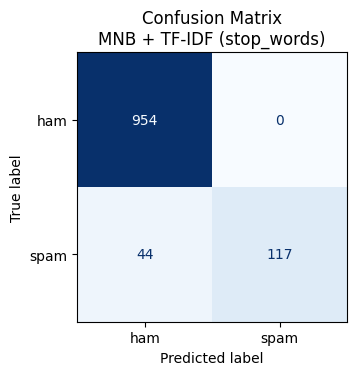

Ham benar dikenali (TN) : 954
Ham salah jadi spam (FP): 0  <- SMS penting bisa terblokir
Spam lolos jadi ham (FN): 44  <- spam masuk inbox
Spam benar dikenali (TP): 117


In [16]:
hasil_tfidf = evaluasi_model('MNB + TF-IDF (stop_words)',
                             mnb_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test)

---
# Perbandingan Hasil Tugas 1 vs Tugas 2

In [17]:
perbandingan = pd.DataFrame([hasil_bow, hasil_tfidf]).set_index('Model')
perbandingan.round(4)

,Akurasi Train,Akurasi Test,Precision (spam),Recall (spam),F1-score (spam)
Model,,,,,
MNB + CountVectorizer (stop_words),0.9946,0.9830,0.9797,0.9006,0.9385
MNB + TF-IDF (stop_words),0.9843,0.9605,1.0000,0.7267,0.8417


## Kesimpulan

| Metrik | CountVectorizer | TF-IDF | Terbaik |
|---|---|---|---|
| Akurasi | 0,9830 | 0,9605 | CountVectorizer |
| Precision (spam) | 0,9797 | 1,0000 | TF-IDF |
| Recall (spam) | 0,9006 | 0,7267 | CountVectorizer |
| F1-score (spam) | 0,9385 | 0,8417 | CountVectorizer |
| Spam lolos (FN) | 16 | 44 | CountVectorizer |
| SMS normal salah masuk spam (FP) | 3 | 0 | TF-IDF |

### Jawaban: fitur terbaik adalah CountVectorizer (dengan stop words)

**Alasannya:**
1. Akurasi lebih tinggi (98,30% vs 96,05%).
2. F1-score spam jauh lebih baik (0,9385 vs 0,8417). Karena data tidak seimbang (spam hanya sekitar 13%), F1-score untuk kelas spam adalah ukuran yang lebih jujur daripada akurasi.
3. Recall spam jauh lebih tinggi (90,1% vs 72,7%). CountVectorizer berhasil menangkap 145 dari 161 spam, sedangkan TF-IDF hanya 117. Artinya TF-IDF membiarkan 44 spam lolos ke inbox.
4. Model CountVectorizer juga tidak overfit: akurasi train 99,5% dan test 98,3% .